# UnmixRate Evaluation with CLIP Surgery

In [1]:
!cd /root/dclip

In [2]:
!pip install -r requirements.txt

In [3]:
import os
import torch
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.datasets import VOCSegmentation
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, InterpolationMode
BICUBIC = InterpolationMode.BICUBIC

In [4]:
# CLIP Surgery import
from CLIP_Surgery import clip as CLIP

/root/dclip/CLIP_Surgery/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [5]:
# 설정
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Device: cuda


In [6]:
VOC_CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

def get_voc_colormap():
    full_map = np.zeros((256, 3), dtype=np.uint8)
    for i in range(256):
        r = g = b = 0
        cid = i
        for j in range(8):
            r |= ((cid >> 0) & 1) << (7 - j)
            g |= ((cid >> 1) & 1) << (7 - j)
            b |= ((cid >> 2) & 1) << (7 - j)
            cid >>= 3
        full_map[i] = [r, g, b]
    return full_map[:21]

VOC_COLORMAP = get_voc_colormap()
VOC_COLORMAP_DICT = {(['background'] + VOC_CLASS_NAMES)[i]: VOC_COLORMAP[i] for i in range(21)}
print("VOC_COLORMAP_DICT loaded.")

VOC_COLORMAP_DICT loaded.


## 1. Similarity CSV 생성 (선택)

In [7]:
# 유사도 CSV가 없으면 생성
SIMILARITY_CSV = 'voc2007_class_similarity_sorted.csv'

if not os.path.exists(SIMILARITY_CSV):
    print("Generating similarity CSV...")
    import clip
    model_for_sim, _ = clip.load('RN101', device=DEVICE)
    
    texts = clip.tokenize(VOC_CLASS_NAMES).to(DEVICE)
    with torch.no_grad():
        text_features = model_for_sim.encode_text(texts)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        text_features = text_features.cpu().numpy()
    
    sim_matrix = np.dot(text_features, text_features.T)
    
    records = []
    for i, cls in enumerate(VOC_CLASS_NAMES):
        sims = sim_matrix[i]
        sorted_idx = np.argsort(sims)
        for j in sorted_idx:
            records.append({
                'class': cls,
                'other_class': VOC_CLASS_NAMES[j],
                'cosine_similarity': float(sims[j])
            })
    
    df = pd.DataFrame.from_records(records)
    df_sorted = df.sort_values(['class', 'cosine_similarity'], ascending=[True, True])
    df_sorted.to_csv(SIMILARITY_CSV, index=False)
    print(f"Saved: {SIMILARITY_CSV}")
    
    del model_for_sim
    torch.cuda.empty_cache()
else:
    print(f"Using existing: {SIMILARITY_CSV}")

Using existing: voc2007_class_similarity_sorted.csv


## 2. CLIP Surgery 모델 로드

In [8]:
MODEL_NAME = "CS-RN101"  # 또는 "CS-ViT-B/16"

model, _ = CLIP.load(MODEL_NAME, device=DEVICE)
model.eval()
print(f"Loaded CLIP Surgery model: {MODEL_NAME}")

Loaded CLIP Surgery model: CS-RN101


## 3. 헬퍼 함수들

In [9]:
def get_top_n_similar_negative_classes(target_class_name, df, n=3):
    """타겟 클래스와 가장 유사한 N개의 다른 클래스 반환"""
    class_specific_df = df[df['class'] == target_class_name].copy()
    class_specific_df_sorted_desc = class_specific_df.sort_values('cosine_similarity', ascending=False)
    
    negative_classes = []
    for _, row in class_specific_df_sorted_desc.iterrows():
        if row['other_class'] != target_class_name:
            negative_classes.append(row['other_class'])
        if len(negative_classes) == n:
            break
    return negative_classes

In [10]:
def perform_zero_shot_segmentation(image, target_class, negative_class_names, clip_model, threshold=0.5, visualize=False):
    """CLIP Surgery를 사용한 Zero-shot Segmentation"""
    device = next(clip_model.parameters()).device
    
    preprocess = Compose([
        Resize((224, 224), interpolation=BICUBIC),
        ToTensor(),
        Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
    ])
    
    pil_img = Image.open(image) if isinstance(image, str) else image
    cv2_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    image_tensor = preprocess(pil_img).unsqueeze(0).to(device)
    target_texts = [target_class] + negative_class_names

    with torch.no_grad():
        image_features = clip_model.encode_image(image_tensor)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = CLIP.encode_text_with_prompt_ensemble(clip_model, target_texts, device)
        similarity = CLIP.clip_feature_surgery(image_features, text_features)
        similarity_map = CLIP.get_similarity_map(similarity[:, 1:, :], cv2_img.shape[:2])

        masks_dict = {}
        for b in range(similarity_map.shape[0]):
            for n in range(similarity_map.shape[-1]):
                vis_gray = similarity_map[b, :, :, n].cpu().numpy()
                vis_gray = (vis_gray - vis_gray.min()) / (vis_gray.max() - vis_gray.min())
                vis_gray = (vis_gray * 255).astype(np.uint8)

                thresh_val = int(256 * threshold)
                _, binary = cv2.threshold(vis_gray, thresh_val, 255, cv2.THRESH_BINARY)
                mask = binary.astype(bool)
                masks_dict[target_texts[n]] = mask

                if visualize:
                    masked_img = np.zeros_like(cv2_img)
                    masked_img[mask] = cv2_img[mask]
                    masked_img = cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB)
                    plt.imshow(masked_img)
                    plt.title(f"Masked: {target_texts[n]}")
                    plt.axis("off")
                    plt.show()
    
    return masks_dict

In [11]:
def compute_iou(mask1, mask2):
    """두 마스크 간 IoU 계산"""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0


def evaluate_image_unmixrate(image_pil, gt_mask, target_class_name, negative_classes, clip_model, threshold, visualize=False):
    """단일 이미지에 대한 UnmixRate 평가"""
    masks = perform_zero_shot_segmentation(
        image=image_pil,
        target_class=target_class_name,
        negative_class_names=negative_classes,
        clip_model=clip_model,
        threshold=threshold,
        visualize=visualize
    )
    
    # IoU 계산
    iou_scores = {}
    for class_name, mask in masks.items():
        iou_scores[class_name] = compute_iou(gt_mask, mask)
    
    # Positive IoU
    positive_iou = iou_scores.get(target_class_name, 0.0)
    
    # Negative IoUs
    negative_ious = [iou_scores[cls] for cls in negative_classes if cls in iou_scores]
    avg_negative_iou = np.mean(negative_ious) if negative_ious else 0.0
    
    # Non-confusion score (1 - avg_negative_iou)
    non_confusion = 1.0 - avg_negative_iou
    
    # UnmixRate (Harmonic Mean)
    if positive_iou > 0 and non_confusion > 0:
        unmix_harmonic = 2.0 / (1.0/positive_iou + 1.0/non_confusion)
    else:
        unmix_harmonic = 0.0
    
    # UnmixRate (Geometric Mean)
    unmix_geometric = np.sqrt(positive_iou * non_confusion)
    
    print(f"  {target_class_name}: Pos_IoU={positive_iou:.4f}, Neg_IoU={avg_negative_iou:.4f}, "
          f"NonConf={non_confusion:.4f}, UnmixRate={unmix_harmonic:.4f}")
    
    return {
        'iou_scores': iou_scores,
        'positive_iou': positive_iou,
        'avg_negative_iou': avg_negative_iou,
        'non_confusion': non_confusion,
        'unmix_harmonic': unmix_harmonic,
        'unmix_geometric': unmix_geometric
    }

## 4. 단일 이미지 테스트

In [12]:
similarity_df = pd.read_csv(SIMILARITY_CSV)

# 데이터셋 로드
voc_dataset = VOCSegmentation(
    root="/root/dclip/data",
    year="2007",
    image_set='val',
    download=False
)
print(f"Loaded VOC dataset: {len(voc_dataset)} images")

Loaded VOC dataset: 213 images


Image #10 - Present classes: ['aeroplane', 'person']


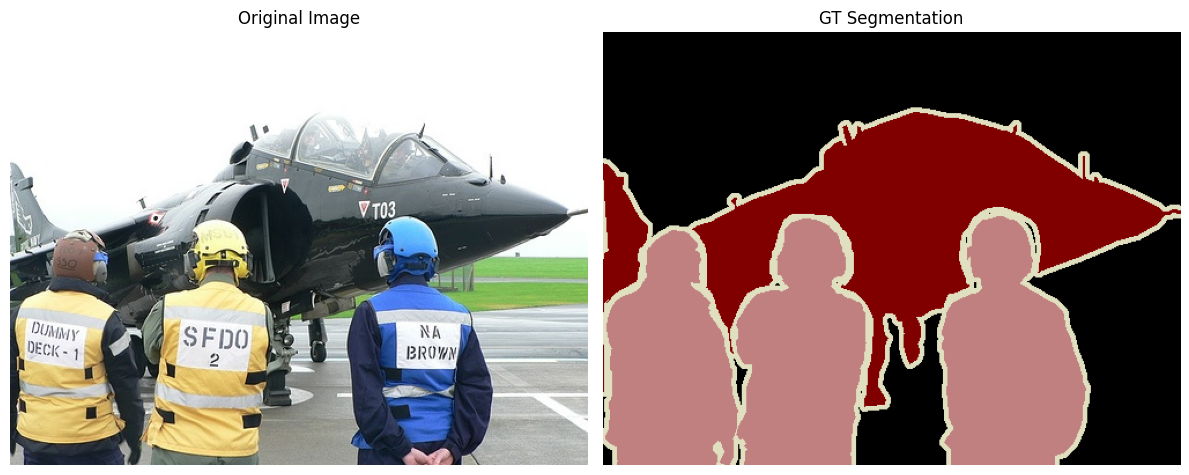

In [13]:
# 샘플 이미지 선택
SAMPLE_IDX = 10

image_pil, gt_mask_pil = voc_dataset[SAMPLE_IDX]
gt_mask_rgb = np.array(gt_mask_pil.convert('RGB'))

# 이미지에 존재하는 클래스 찾기
present_classes = []
unique_colors = np.unique(gt_mask_rgb.reshape(-1, 3), axis=0)
for color in unique_colors:
    for cls_name, cls_color in VOC_COLORMAP_DICT.items():
        if cls_name != 'background' and np.array_equal(color, cls_color):
            present_classes.append(cls_name)

print(f"Image #{SAMPLE_IDX} - Present classes: {present_classes}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_pil)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(gt_mask_pil)
axes[1].set_title("GT Segmentation")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Target: aeroplane, Negatives: ['train', 'car', 'boat']


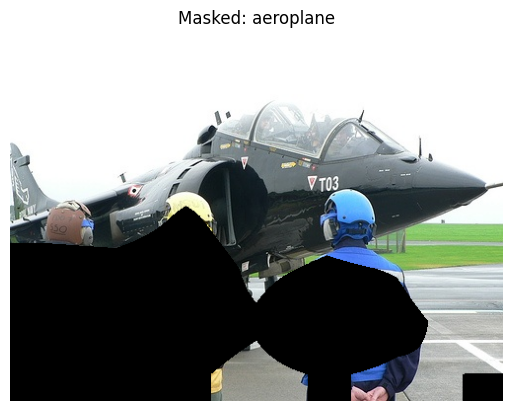

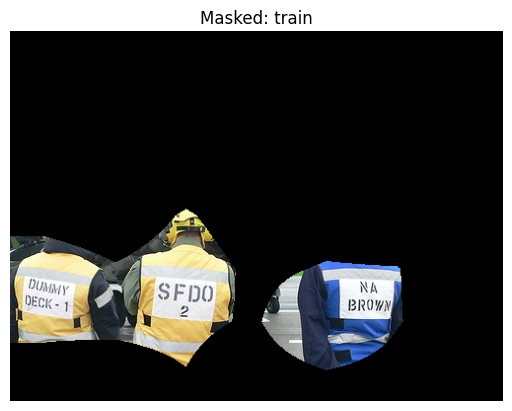

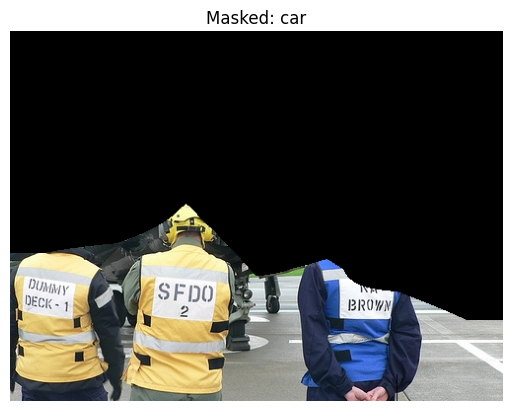

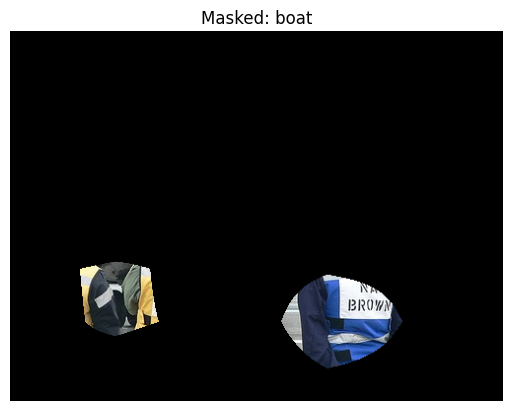

  aeroplane: Pos_IoU=0.2702, Neg_IoU=0.0187, NonConf=0.9813, UnmixRate=0.4237


In [14]:
# 첫 번째 클래스에 대해 UnmixRate 평가
if len(present_classes) > 0:
    TARGET_CLASS = present_classes[0]
    N_NEGATIVE = 3
    THRESHOLD = 0.5
    
    # 유사한 Negative 클래스 찾기
    negative_classes = get_top_n_similar_negative_classes(TARGET_CLASS, similarity_df, n=N_NEGATIVE)
    print(f"Target: {TARGET_CLASS}, Negatives: {negative_classes}")
    
    # GT 마스크 추출
    target_color = VOC_COLORMAP_DICT[TARGET_CLASS]
    gt_target_mask = np.all(gt_mask_rgb == target_color, axis=-1)
    
    # 평가
    result = evaluate_image_unmixrate(
        image_pil=image_pil,
        gt_mask=gt_target_mask,
        target_class_name=TARGET_CLASS,
        negative_classes=negative_classes,
        clip_model=model,
        threshold=THRESHOLD,
        visualize=True
    )
else:
    print("No classes found in this image.")

## 5. 전체 데이터셋 평가

In [15]:
def run_unmixrate_evaluation_voc(
    clip_model,
    model_name="CS-RN101",
    similarity_df_path="voc2007_class_similarity_sorted.csv",
    voc_root="datasets",
    year="2012",
    image_set='val',
    n_negative=3,
    threshold=0.5,
    visualize=False
):
    """VOC 데이터셋에 대한 UnmixRate 평가 실행"""
    print("="*60)
    print("UnmixRate Evaluation")
    print("="*60)
    print(f"Model: {model_name}")
    print(f"Dataset: VOC{year} {image_set}")
    print(f"N negative: {n_negative}, Threshold: {threshold}")
    print("="*60)
    
    # 데이터 로드
    similarity_df = pd.read_csv(similarity_df_path)
    voc_dataset = VOCSegmentation(
        root=voc_root,
        year=year,
        image_set=image_set,
        download=False
    )
    print(f"Loaded {len(voc_dataset)} images.")
    
    all_results = []
    
    for i in range(len(voc_dataset)):
        if i % 10 == 0:
            print(f"\nProcessing image {i+1}/{len(voc_dataset)}...")
        
        image_pil, gt_mask_pil = voc_dataset[i]
        gt_mask_rgb = np.array(gt_mask_pil.convert('RGB'))
        
        # 이미지 ID
        image_id = os.path.basename(voc_dataset.images[i]).split('.')[0]
        
        # 이미지에 존재하는 클래스 찾기
        present_classes = []
        unique_colors = np.unique(gt_mask_rgb.reshape(-1, 3), axis=0)
        for color in unique_colors:
            for cls_name, cls_color in VOC_COLORMAP_DICT.items():
                if cls_name != 'background' and np.array_equal(color, cls_color):
                    present_classes.append(cls_name)
        
        # 각 클래스에 대해 평가
        for target_class in present_classes:
            # 유사한 Negative 클래스
            negative_classes = get_top_n_similar_negative_classes(target_class, similarity_df, n=n_negative)
            if not negative_classes:
                continue
            
            # GT 마스크 추출
            target_color = VOC_COLORMAP_DICT[target_class]
            gt_target_mask = np.all(gt_mask_rgb == target_color, axis=-1)
            
            if gt_target_mask.sum() == 0:
                continue
            
            # 평가
            result = evaluate_image_unmixrate(
                image_pil=image_pil,
                gt_mask=gt_target_mask,
                target_class_name=target_class,
                negative_classes=negative_classes,
                clip_model=clip_model,
                threshold=threshold,
                visualize=visualize
            )
            
            all_results.append({
                'image_id': image_id,
                'target_class': target_class,
                'negative_classes': ','.join(negative_classes),
                'positive_iou': result['positive_iou'],
                'avg_negative_iou': result['avg_negative_iou'],
                'non_confusion': result['non_confusion'],
                'unmix_harmonic': result['unmix_harmonic'],
                'unmix_geometric': result['unmix_geometric']
            })
    
    # 결과 DataFrame
    results_df = pd.DataFrame(all_results)
    
    if not results_df.empty:
        # 통계 출력
        print("\n" + "="*60)
        print("Results Summary")
        print("="*60)
        print(f"Total samples: {len(results_df)}")
        print(f"Avg Positive IoU: {results_df['positive_iou'].mean():.4f}")
        print(f"Avg Negative IoU: {results_df['avg_negative_iou'].mean():.4f}")
        print(f"Avg Non-Confusion: {results_df['non_confusion'].mean():.4f}")
        print(f"Avg UnmixRate (Harmonic): {results_df['unmix_harmonic'].mean():.4f}")
        print(f"Avg UnmixRate (Geometric): {results_df['unmix_geometric'].mean():.4f}")
        
        # 클래스별 UnmixRate
        print("\nPer-class UnmixRate (Harmonic):")
        per_class = results_df.groupby('target_class')['unmix_harmonic'].mean().sort_values(ascending=False)
        for cls, score in per_class.items():
            print(f"  {cls:15s}: {score:.4f}")
        
        # CSV 저장
        avg_unmix = results_df['unmix_harmonic'].mean()
        output_path = f"unmixrate_voc{year}_{image_set}_{model_name.replace('/', '-')}_t{threshold}_N{n_negative}_{avg_unmix:.4f}.csv"
        results_df.to_csv(output_path, index=False)
        print(f"\nResults saved to: {output_path}")
    
    return results_df

In [16]:
# 전체 평가 실행
results_df = run_unmixrate_evaluation_voc(
    clip_model=model,
    model_name=MODEL_NAME,
    similarity_df_path=SIMILARITY_CSV,
    voc_root="/root/dclip/data",
    year="2007",
    image_set="val",
    n_negative=3,
    threshold=0.5,
    visualize=False
)

UnmixRate Evaluation
Model: CS-RN101
Dataset: VOC2007 val
N negative: 3, Threshold: 0.5
Loaded 213 images.

Processing image 1/213...
  tvmonitor: Pos_IoU=0.3909, Neg_IoU=0.1076, NonConf=0.8924, UnmixRate=0.5437
  dog: Pos_IoU=0.5979, Neg_IoU=0.0177, NonConf=0.9823, UnmixRate=0.7433
  chair: Pos_IoU=0.4712, Neg_IoU=0.1781, NonConf=0.8219, UnmixRate=0.5990


  tvmonitor: Pos_IoU=0.5063, Neg_IoU=0.0954, NonConf=0.9046, UnmixRate=0.6492
  train: Pos_IoU=0.4336, Neg_IoU=0.0559, NonConf=0.9441, UnmixRate=0.5942
  bottle: Pos_IoU=0.0483, Neg_IoU=0.0030, NonConf=0.9970, UnmixRate=0.0922
  person: Pos_IoU=0.6450, Neg_IoU=0.1875, NonConf=0.8125, UnmixRate=0.7191
  boat: Pos_IoU=0.0636, Neg_IoU=0.0004, NonConf=0.9996, UnmixRate=0.1195
  person: Pos_IoU=0.8126, Neg_IoU=0.2761, NonConf=0.7239, UnmixRate=0.7657
  horse: Pos_IoU=0.4641, Neg_IoU=0.1679, NonConf=0.8321, UnmixRate=0.5958
  bird: Pos_IoU=0.5505, Neg_IoU=0.0433, NonConf=0.9567, UnmixRate=0.6989
  cow: Pos_IoU=0.3856, Neg_IoU=0.1177, NonConf=0.8823, UnmixRate=0.5366

Processing image 11/213...
  aeroplane: Pos_IoU=0.2702, Neg_IoU=0.0187, NonConf=0.9813, UnmixRate=0.4237
  person: Pos_IoU=0.6073, Neg_IoU=0.1352, NonConf=0.8648, UnmixRate=0.7135
  cow: Pos_IoU=0.7772, Neg_IoU=0.1139, NonConf=0.8861, UnmixRate=0.8281
  bicycle: Pos_IoU=0.0251, Neg_IoU=0.0138, NonConf=0.9862, UnmixRate=0.0490
  

## 6. 결과 시각화

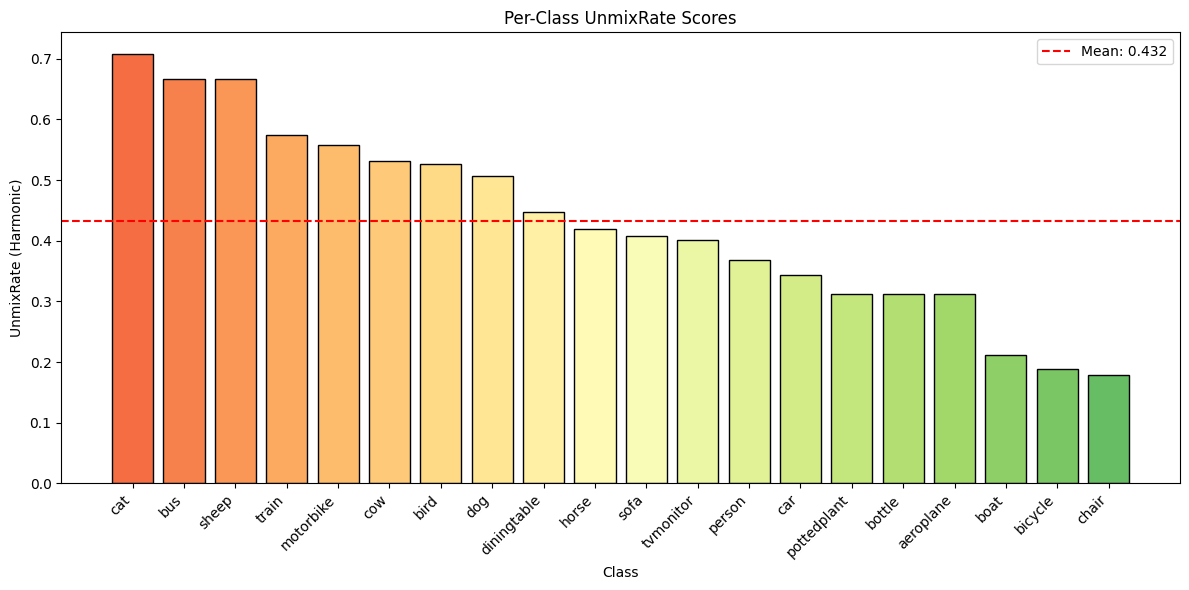

In [17]:
if len(results_df) > 0:
    # 클래스별 UnmixRate 바 차트
    per_class = results_df.groupby('target_class')['unmix_harmonic'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(per_class)))
    plt.bar(per_class.index, per_class.values, color=colors, edgecolor='black')
    plt.axhline(y=per_class.mean(), color='red', linestyle='--', label=f'Mean: {per_class.mean():.3f}')
    plt.xlabel('Class')
    plt.ylabel('UnmixRate (Harmonic)')
    plt.title('Per-Class UnmixRate Scores')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

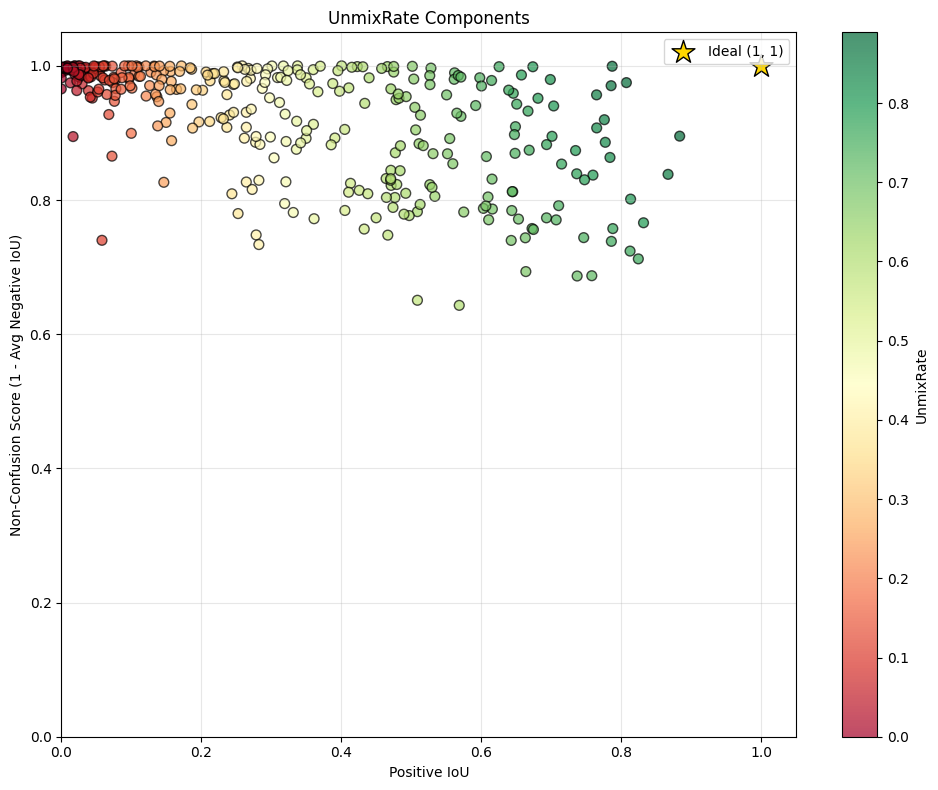

In [18]:
if len(results_df) > 0:
    # Positive IoU vs Non-Confusion 산점도
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        results_df['positive_iou'],
        results_df['non_confusion'],
        c=results_df['unmix_harmonic'],
        cmap='RdYlGn',
        alpha=0.7,
        s=50,
        edgecolors='black'
    )
    plt.colorbar(scatter, label='UnmixRate')
    plt.xlabel('Positive IoU')
    plt.ylabel('Non-Confusion Score (1 - Avg Negative IoU)')
    plt.title('UnmixRate Components')
    plt.scatter([1], [1], marker='*', s=300, c='gold', edgecolors='black', label='Ideal (1, 1)')
    plt.legend()
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
# 최종 요약
if len(results_df) > 0:
    print("\n" + "="*60)
    print("Final Summary")
    print("="*60)
    print(f"Model: {MODEL_NAME}")
    print(f"Total samples: {len(results_df)}")
    print(f"Avg UnmixRate (Harmonic): {results_df['unmix_harmonic'].mean():.4f}")
    print(f"Avg UnmixRate (Geometric): {results_df['unmix_geometric'].mean():.4f}")
    print("\nTop 5 classes:")
    top5 = results_df.groupby('target_class')['unmix_harmonic'].mean().sort_values(ascending=False).head(5)
    for cls, score in top5.items():
        print(f"  {cls}: {score:.4f}")
    print("\nBottom 5 classes:")
    bottom5 = results_df.groupby('target_class')['unmix_harmonic'].mean().sort_values(ascending=True).head(5)
    for cls, score in bottom5.items():
        print(f"  {cls}: {score:.4f}")
    print("="*60)


Final Summary
Model: CS-RN101
Total samples: 344
Avg UnmixRate (Harmonic): 0.4181
Avg UnmixRate (Geometric): 0.4845

Top 5 classes:
  cat: 0.7083
  bus: 0.6671
  sheep: 0.6671
  train: 0.5736
  motorbike: 0.5571

Bottom 5 classes:
  chair: 0.1780
  bicycle: 0.1881
  boat: 0.2110
  aeroplane: 0.3115
  bottle: 0.3119
